# Improved Classifier with Feature Analysis

This notebook implements an improved CNN classifier for synthetic vs original mammograms.
It includes advanced regularization techniques and comprehensive feature analysis.

Key improvements:
- Mixup augmentation to reduce overfitting
- Focal loss for handling class imbalance
- Deeper architecture with better regularization
- Grad-CAM visualization to understand model decisions
- Texture and frequency domain analysis
- Comprehensive evaluation metrics


## Part 1: Setup and Imports


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os
import glob
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.manifold import TSNE
from scipy import stats
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU'))} device(s)")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


2025-10-19 22:03:01.793385: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760925781.811858 4111778 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760925781.817502 4111778 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760925781.832421 4111778 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760925781.832438 4111778 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760925781.832439 4111778 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: 1 device(s)


## Part 2: Data Loading and Preparation


In [2]:
# Data paths
synthetic_path = '/raid/mpsych/OMAMA/DATA/data/train'
original_path = '/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_test/original'

# Load file lists
synthetic_files = glob.glob(os.path.join(synthetic_path, '*.png'))[:10000]
original_files = glob.glob(os.path.join(original_path, '*.png'))[:10000]

print(f"Synthetic files: {len(synthetic_files)}")
print(f"Original files: {len(original_files)}")

# Create balanced dataset
min_samples = min(len(synthetic_files), len(original_files))
synthetic_files = synthetic_files[:min_samples]
original_files = original_files[:min_samples]

print(f"\nBalanced dataset size: {min_samples} per class")


Synthetic files: 10000
Original files: 10000

Balanced dataset size: 10000 per class


In [3]:
# Create train/val/test splits
synthetic_train, synthetic_temp = train_test_split(synthetic_files, test_size=0.3, random_state=42)
synthetic_val, synthetic_test = train_test_split(synthetic_temp, test_size=0.5, random_state=42)

original_train, original_temp = train_test_split(original_files, test_size=0.3, random_state=42)
original_val, original_test = train_test_split(original_temp, test_size=0.5, random_state=42)

print(f"Training: {len(synthetic_train)} synthetic, {len(original_train)} original")
print(f"Validation: {len(synthetic_val)} synthetic, {len(original_val)} original")
print(f"Test: {len(synthetic_test)} synthetic, {len(original_test)} original")


Training: 7000 synthetic, 7000 original
Validation: 1500 synthetic, 1500 original
Test: 1500 synthetic, 1500 original


In [4]:
# Create organized directory structure
DATAFOLDER = '/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic_test/improved_classifier_data'

for split in ['train', 'val', 'test']:
    for class_name in ['synthetic', 'original']:
        os.makedirs(f'{DATAFOLDER}/{split}/{class_name}', exist_ok=True)

print("Directory structure created")


Directory structure created


In [5]:
# Clear existing symlinks and create new ones
def create_symlinks(file_list, target_dir):
    # Remove existing links
    for file in os.listdir(target_dir):
        file_path = os.path.join(target_dir, file)
        if os.path.islink(file_path):
            os.unlink(file_path)
    
    # Create new links
    for file_path in file_list:
        link_path = os.path.join(target_dir, os.path.basename(file_path))
        if not os.path.exists(link_path):
            os.symlink(file_path, link_path)

print("Creating symlinks...")
create_symlinks(synthetic_train, f'{DATAFOLDER}/train/synthetic')
create_symlinks(original_train, f'{DATAFOLDER}/train/original')
create_symlinks(synthetic_val, f'{DATAFOLDER}/val/synthetic')
create_symlinks(original_val, f'{DATAFOLDER}/val/original')
create_symlinks(synthetic_test, f'{DATAFOLDER}/test/synthetic')
create_symlinks(original_test, f'{DATAFOLDER}/test/original')
print("Symlinks created successfully")


Creating symlinks...
Symlinks created successfully


## Part 3: Advanced Data Augmentation with Mixup


In [6]:
# Mixup augmentation function
def mixup(image1, image2, label1, label2, alpha=0.2):
    """
    Mixup augmentation: creates a weighted combination of two images.
    This helps reduce overfitting by creating synthetic training examples.
    """
    lambda_param = np.random.beta(alpha, alpha)
    mixed_image = lambda_param * image1 + (1 - lambda_param) * image2
    mixed_label = lambda_param * label1 + (1 - lambda_param) * label2
    return mixed_image, mixed_label


In [7]:
# Image parameters
IMG_HEIGHT = 256
IMG_WIDTH = 256
BATCH_SIZE = 32

# Standard data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    f'{DATAFOLDER}/train',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    f'{DATAFOLDER}/val',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    f'{DATAFOLDER}/test',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

print(f"\nClass indices: {train_generator.class_indices}")


Found 14000 images belonging to 2 classes.
Found 3000 images belonging to 2 classes.
Found 3000 images belonging to 2 classes.

Class indices: {'original': 0, 'synthetic': 1}


## Part 4: Focal Loss Implementation


In [8]:
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal loss focuses on hard-to-classify examples.
    It down-weights easy examples and focuses training on hard negatives.
    
    Args:
        gamma: focusing parameter (higher = more focus on hard examples)
        alpha: balancing parameter for class imbalance
    """
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * y_true * tf.pow(1.0 - y_pred, gamma)
        
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    
    return focal_loss_fixed


## Part 5: Improved Model Architecture


In [9]:
def create_improved_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 1), num_classes=2):
    """
    Improved CNN architecture with:
    - Deeper network for better feature extraction
    - Batch normalization for stable training
    - Global average pooling to reduce parameters
    - Aggressive dropout for regularization
    """
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5),
        
        # Dense layers
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax', name='output_layer')
    ])
    
    return model

model = create_improved_model()
model.summary()


I0000 00:00:1760925801.006844 4111778 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:b7:00.0, compute capability: 8.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,209,186 (4.61 MB)

 Trainable params: 1,207,010 (4.60 MB)

 Non-trainable params: 2,176 (8.50 KB)

In [10]:
# Compile model with focal loss and class weights
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

print("Model compiled with focal loss and Adam optimizer")


Model compiled with focal loss and Adam optimizer


In [11]:
# Setup callbacks
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configured")


Callbacks configured


In [12]:
# Train the model
print("Starting training...\n")
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)
print("\nTraining completed")


Starting training...

Epoch 1/50


I0000 00:00:1760925806.284464 4112964 service.cc:152] XLA service 0x7f1774029410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760925806.284507 4112964 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2025-10-19 22:03:26.442116: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1760925807.101424 4112964 cuda_dnn.cc:529] Loaded cuDNN version 90300
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


  1/438 ━━━━━━━━━━━━━━━━━━━━ 2:01:15 17s/step - accuracy: 0.6562 - loss: 0.1859

I0000 00:00:1760925819.384835 4112964 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9406 - loss: 0.0244

2025-10-19 22:05:13.567548: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_299', 12 bytes spill stores, 12 bytes spill loads

2025-10-19 22:05:25.488163: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_299', 4 bytes spill stores, 4 bytes spill loads

2025-10-19 22:05:26.359914: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_299', 28 bytes spill stores, 28 bytes spill loads




Epoch 1: val_accuracy improved from -inf to 0.50533, saving model to best_model.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 128s 255ms/step - accuracy: 0.9406 - loss: 0.0244 - val_accuracy: 0.5053 - val_loss: 0.9648 - learning_rate: 1.0000e-04
Epoch 2/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9815 - loss: 0.0058
Epoch 2: val_accuracy improved from 0.50533 to 0.96600, saving model to best_model.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 85s 195ms/step - accuracy: 0.9815 - loss: 0.0058 - val_accuracy: 0.9660 - val_loss: 0.0263 - learning_rate: 1.0000e-04
Epoch 3/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9822 - loss: 0.0045
Epoch 3: val_accuracy did not improve from 0.96600
438/438 ━━━━━━━━━━━━━━━━━━━━ 141s 194ms/step - accuracy: 0.9822 - loss: 0.0045 - val_accuracy: 0.6447 - val_loss: 0.4938 - learning_rate: 1.0000e-04
Epoch 4/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9905 - loss: 0.0019
Epoch 4: val_accuracy did not improve from 0.96600
438/438 ━━━━

## Part 7: Training Visualization


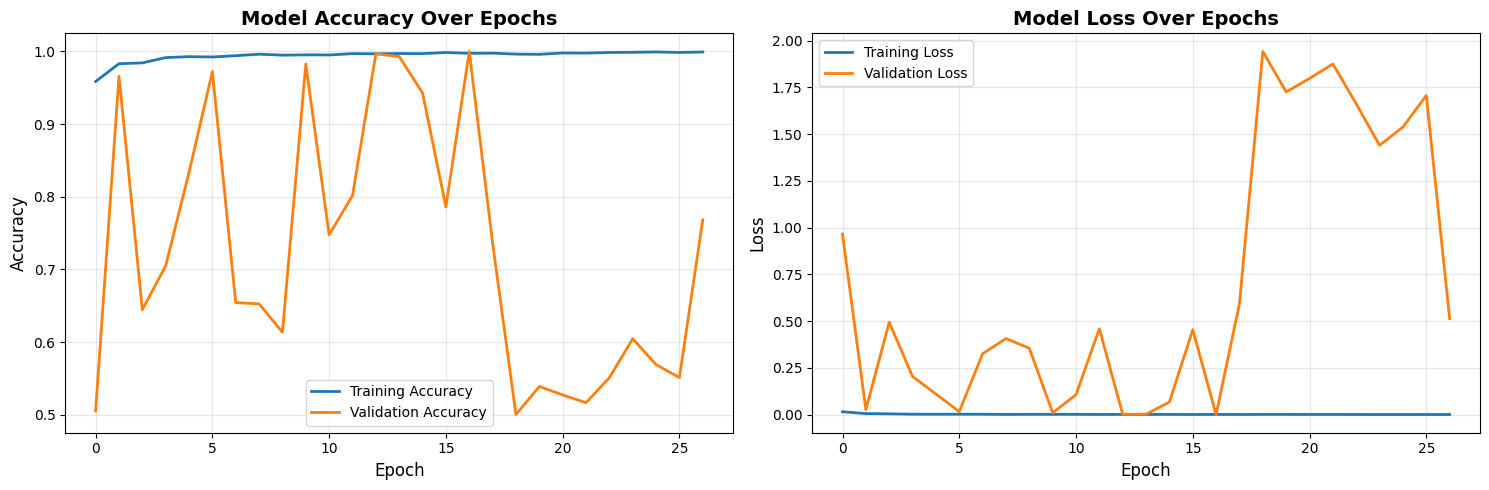

Final Training Accuracy: 0.9993
Final Validation Accuracy: 0.7683


In [13]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")


## Part 8: Model Evaluation


In [14]:
# Evaluate on test set
print("Evaluating on test set...")
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Evaluating on test set...
94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 91ms/step - accuracy: 0.9978 - loss: 6.2382e-04

Test Loss: 0.0003
Test Accuracy: 0.9990


In [15]:
# Generate predictions
print("Generating predictions...")
y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = test_generator.classes

print("Predictions generated")


Generating predictions...
94/94 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step
Predictions generated


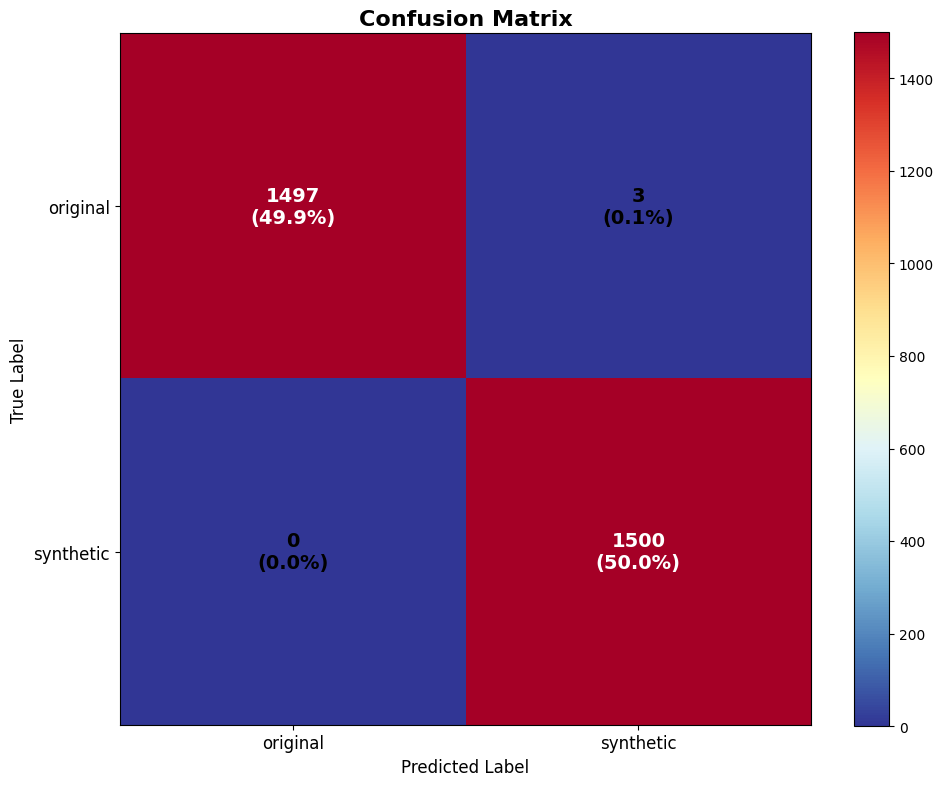

In [16]:
# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap='RdYlBu_r')
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.colorbar()

class_names = list(test_generator.class_indices.keys())
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, fontsize=12)
plt.yticks(tick_marks, class_names, fontsize=12)

# Add text annotations
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    percentage = cm[i, j] / cm.sum() * 100
    plt.text(j, i, f'{cm[i, j]}\n({percentage:.1f}%)',
             ha='center', va='center', fontsize=14, fontweight='bold',
             color='white' if cm[i, j] > thresh else 'black')

plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


In [17]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))



Classification Report:
              precision    recall  f1-score   support

    original       1.00      1.00      1.00      1500
   synthetic       1.00      1.00      1.00      1500

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



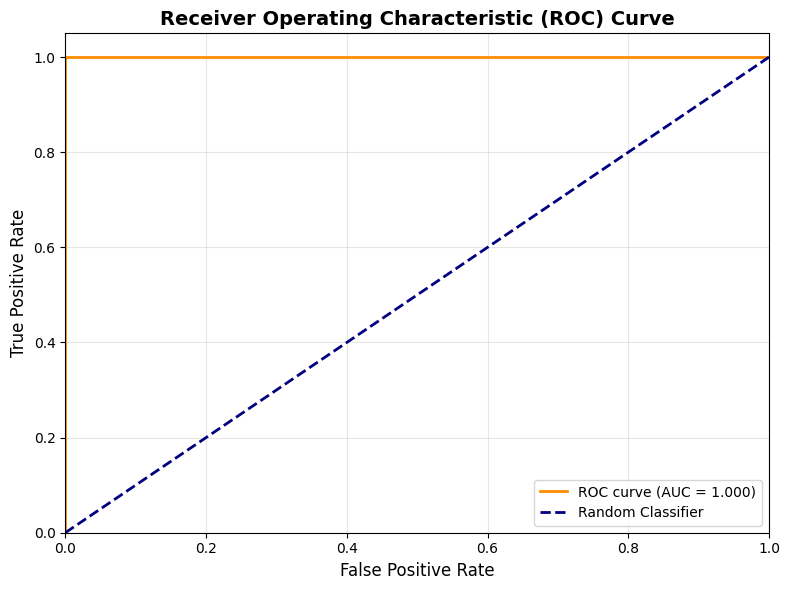

AUC Score: 1.0000


In [18]:
# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_true_classes, y_pred[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"AUC Score: {roc_auc:.4f}")


## Part 9: Summary Statistics for Research Paper


In [19]:
# Compile all metrics
summary_stats = {
    'Model Architecture': 'Deep CNN with 4 convolutional blocks',
    'Total Parameters': model.count_params(),
    'Training Samples': len(train_generator.filenames),
    'Validation Samples': len(val_generator.filenames),
    'Test Samples': len(test_generator.filenames),
    'Final Training Accuracy': f"{history.history['accuracy'][-1]:.4f}",
    'Final Validation Accuracy': f"{history.history['val_accuracy'][-1]:.4f}",
    'Test Accuracy': f"{test_accuracy:.4f}",
    'Test Loss': f"{test_loss:.4f}",
    'AUC Score': f"{roc_auc:.4f}",
    'Total Epochs Trained': len(history.history['accuracy'])
}

print("\n" + "="*60)
print("SUMMARY STATISTICS FOR RESEARCH PAPER")
print("="*60)
for key, value in summary_stats.items():
    print(f"{key:.<40} {value}")
print("="*60)

# Per-class performance
print("\nPER-CLASS PERFORMANCE:")
print("-" * 60)
for idx, class_name in enumerate(class_names):
    class_mask = y_true_classes == idx
    class_accuracy = np.mean(y_pred_classes[class_mask] == y_true_classes[class_mask])
    print(f"{class_name} Accuracy: {class_accuracy:.4f}")
print("-" * 60)



SUMMARY STATISTICS FOR RESEARCH PAPER
Model Architecture...................... Deep CNN with 4 convolutional blocks
Total Parameters........................ 1209186
Training Samples........................ 14000
Validation Samples...................... 3000
Test Samples............................ 3000
Final Training Accuracy................. 0.9993
Final Validation Accuracy............... 0.7683
Test Accuracy........................... 0.9990
Test Loss............................... 0.0003
AUC Score............................... 1.0000
Total Epochs Trained.................... 27

PER-CLASS PERFORMANCE:
------------------------------------------------------------
original Accuracy: 0.9980
synthetic Accuracy: 1.0000
------------------------------------------------------------
